<a href="https://colab.research.google.com/github/aditi1295/MachineLearning/blob/main/PCAExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd

In [6]:
df=pd.read_csv('/content/mnist_test.csv')

In [7]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.sample()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
49,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
import matplotlib.pyplot as plt


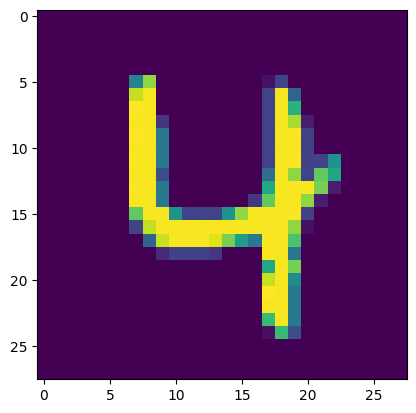

In [13]:
plt.imshow(df.iloc[49,1:].values.reshape(28,28))

In [14]:
X=df.iloc[:,1:]
Y=df.iloc[:,0]

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
X_train.shape

(461, 784)

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)   # fit_transform nahi

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
knn=KNeighborsClassifier()

In [25]:
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [27]:
 import time
 start=time.time()
 y_pred=knn.predict(X_test)
 print(time.time()-start)

0.0975944995880127


In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.7586206896551724

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [30]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=50)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [31]:
X_train_trf.shape

(461, 50)

In [32]:
knn=KNeighborsClassifier()

In [33]:
knn.fit(X_train_trf,Y_train)

KNeighborsClassifier()

In [34]:
y_pred=knn.predict(X_test_trf)

In [35]:
accuracy_score(Y_test,y_pred)

0.8362068965517241

In [36]:
for i in range(1,785):
  pca=PCA(n_components=i)
  X_train_trf=pca.fit_transform(X_train)
  X_test_trf=pca.transform(X_test)
  knn=KNeighborsClassifier()
  knn.fit(X_train_trf,Y_train)
  y_pred=knn.predict(X_test_trf)
  print( accuracy_score(Y_test,y_pred))


0.2413793103448276
0.3879310344827586
0.4482758620689655
0.5172413793103449
0.7155172413793104
0.75
0.7672413793103449
0.7672413793103449
0.7758620689655172
0.8103448275862069
0.8017241379310345
0.8017241379310345
0.8103448275862069
0.8189655172413793
0.8275862068965517
0.8275862068965517
0.8448275862068966
0.853448275862069
0.853448275862069
0.8620689655172413
0.853448275862069
0.8275862068965517
0.8362068965517241
0.8103448275862069
0.8362068965517241
0.8103448275862069
0.8103448275862069
0.8103448275862069
0.8275862068965517
0.8362068965517241
0.8448275862068966
0.8448275862068966
0.8448275862068966
0.8275862068965517
0.8275862068965517
0.8103448275862069
0.8103448275862069
0.8189655172413793
0.8362068965517241
0.8189655172413793
0.8362068965517241
0.8448275862068966
0.8189655172413793
0.8189655172413793
0.8362068965517241
0.8448275862068966
0.8275862068965517
0.8362068965517241
0.8275862068965517
0.8275862068965517
0.8189655172413793
0.8275862068965517
0.8189655172413793
0.81896551

KeyboardInterrupt: 

#Data Visualization

In [37]:
pca=PCA(n_components=2)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [38]:
X_train_trf

array([[-1.88095627e+00, -3.28629662e-01],
       [-8.38831373e-01, -3.53134385e-01],
       [-1.54035101e+00, -4.71640330e+00],
       [ 2.10612514e+00, -1.09978721e+00],
       [-7.92378171e-02,  1.39027517e+01],
       [ 4.06107090e+00, -5.68886386e+00],
       [ 5.70586938e+00, -3.01202455e+00],
       [-4.42292071e-01, -7.35258807e-01],
       [-6.14364499e+00,  2.93300436e-01],
       [ 1.71482610e+00,  8.34815622e+00],
       [ 6.31852217e+00,  5.21088349e-01],
       [ 1.07056805e+01,  5.44274001e-01],
       [ 4.18649919e+00,  9.37877923e+00],
       [-4.08385406e+00, -3.41052931e+00],
       [-2.01732555e+00,  1.51945518e-01],
       [ 1.05289780e+01, -2.11484728e+00],
       [-4.10795624e+00,  3.98160869e+00],
       [-1.24715428e+00,  2.35930693e+00],
       [ 1.42099522e+01, -4.55584293e+00],
       [-8.62836494e+00, -2.02926341e+00],
       [-1.18803409e+00,  5.58032707e+00],
       [ 2.06832560e+00,  1.08324922e+00],
       [-4.97281099e+00, -2.86954929e+00],
       [-5.

In [39]:
#2D
import plotly.express as px
Y_train_trf=Y_train.astype(str)
fig=px.scatter(x=X_train_trf[:,0],
               y=X_train_trf[:,1],
               color=Y_train_trf,
               color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [40]:
#transforming in 3D
pca=PCA(n_components=3)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [41]:
X_train_trf

array([[-1.88110814, -0.32938698,  4.1060366 ],
       [-0.83895436, -0.35518689,  6.64391409],
       [-1.54028422, -4.71588825,  0.90367765],
       ...,
       [-0.16539894, -2.44861208, -3.52660187],
       [-5.20935527, -0.90499569,  3.08762674],
       [ 0.06209618,  4.0280663 ,  5.87620512]])

In [42]:
Y_train_trf=Y_train.astype(str)
fig=px.scatter_3d(x=X_train_trf[:,0],
               y=X_train_trf[:,1],
               z=X_train_trf[:,2],
               color=Y_train_trf)
fig.update_layout(margin=dict(l=20,r=20,b=20))
fig.show()

In [43]:
pca.explained_variance_
#eigen values

array([43.45990156, 29.02003955, 24.08191301])

In [46]:
pca.components_
#eigrn vectors

array([[-2.30267154e-18,  1.15142034e-19,  3.43390757e-20, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-7.64176908e-17, -3.03253745e-17, -1.21012124e-18, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-5.77940782e-17,  4.29433927e-17,  4.00416002e-18, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00]])

In [47]:
pca.components_.shape

(3, 784)

In [48]:
#optimom number batna ki kitne fix vector ho taki unka eigen vector find kare pca me bar bar loop na chalna pade
pca.explained_variance_ratio_

array([0.07634794, 0.05098079, 0.04230577])

In [49]:
#transforming in 3D
pca=PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [52]:
pca.explained_variance_.shape

(461,)

In [51]:
pca.components_.shape

(461, 784)

In [54]:
np.cumsum(pca.explained_variance_ratio_)

array([0.07634794, 0.12732874, 0.16963459, 0.20919535, 0.24297481,
       0.27109543, 0.29639003, 0.31997222, 0.34226367, 0.36153177,
       0.3804324 , 0.39743973, 0.41352563, 0.42885377, 0.44386253,
       0.45779196, 0.47167157, 0.48525731, 0.49815457, 0.51095188,
       0.52291469, 0.53446321, 0.5456845 , 0.556543  , 0.56726593,
       0.57729706, 0.58728767, 0.59713098, 0.60643785, 0.61567939,
       0.62449448, 0.63289385, 0.64106995, 0.64906276, 0.65682606,
       0.66441319, 0.6717347 , 0.6788121 , 0.68563274, 0.69217845,
       0.69861846, 0.70484276, 0.71101023, 0.71708891, 0.72300731,
       0.72879471, 0.73454784, 0.74004586, 0.74536358, 0.75057658,
       0.75558459, 0.76050099, 0.76526112, 0.76984199, 0.77434816,
       0.77875992, 0.78303912, 0.78727875, 0.79142706, 0.79546929,
       0.79937346, 0.80322864, 0.8070301 , 0.8107885 , 0.81442944,
       0.81795987, 0.82137198, 0.82473816, 0.82806271, 0.83134298,
       0.83454431, 0.837639  , 0.84067616, 0.84365854, 0.84659

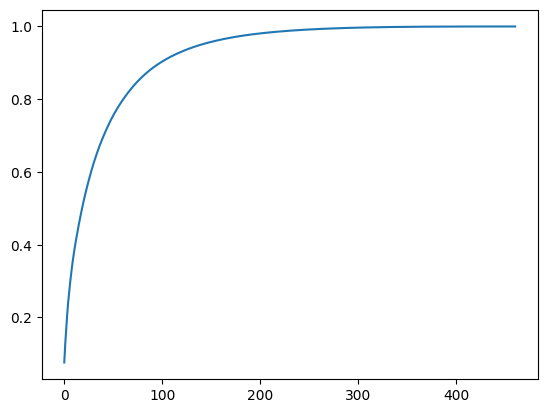

In [55]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))